# 05 Baseline Models (Logistic Regression + Naive Bayes)

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB

In [25]:
DRIVE_ROOT    = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURES_DIR  = f'{DRIVE_ROOT}/data/features'
PROCESSED_DIR = f'{DRIVE_ROOT}/data/processed'
OUTPUT_DIR    = '/content/drive/MyDrive/SmartReviewAnalyzer_baseline'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load TF-IDF features
print("Loading TF-IDF features...")
X_train_tfidf = sp.load_npz(f'{FEATURES_DIR}/X_train_tfidf.npz')
X_test_tfidf  = sp.load_npz(f'{FEATURES_DIR}/X_test_tfidf.npz')
tfidf         = joblib.load(f'{FEATURES_DIR}/tfidf_vectorizer.joblib')
# Load labels
labels   = np.load(f'{FEATURES_DIR}/labels.npz')
y_train  = labels['y_train']
y_test   = labels['y_test']

print(f"\nFeature shapes")
print(f"TF-IDF train : {X_train_tfidf.shape}")
print(f"TF-IDF test  : {X_test_tfidf.shape}")
print(f"y_train      : {y_train.shape}  | Positive: {y_train.sum():,} | Negative: {(y_train==0).sum():,}")
print(f"y_test       : {y_test.shape}   | Positive: {y_test.sum():,}  | Negative: {(y_test==0).sum():,}")

Loading TF-IDF features...

Feature shapes
TF-IDF train : (519575, 50000)
TF-IDF test  : (39972, 50000)
y_train      : (519575,)  | Positive: 259,844 | Negative: 259,731
y_test       : (39972,)   | Positive: 19,991  | Negative: 19,981


#  Unified evaluation function

In [26]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Negative', 'Positive']))

    return {
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1'       : round(f1,   4),
        'ROC-AUC'  : round(auc,  4) if auc else None,
    }


def plot_confusion_matrix(name, y_true, y_pred, save_path=None):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, pad=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    plt.show()

print("Evaluation helpers ready.")

Evaluation helpers ready.


# Logistic Regression

In [27]:
print("Training Logistic Regression on TF-IDF features...")
print(f"Training set size: {X_train_tfidf.shape[0]:,} samples × {X_train_tfidf.shape[1]:,} features")

t0 = time.time()

lr_tfidf = LogisticRegression(
    C          = 1.0,          # regularization strength
    solver     = 'saga',       # best solver for large sparse data
    max_iter   = 1000,
    n_jobs     = -1,           # use all CPU cores
    random_state = 42,
    verbose    = 1
)

lr_tfidf.fit(X_train_tfidf, y_train)
elapsed = time.time() - t0
print(f"\nTraining time: {elapsed:.1f}s")


Training Logistic Regression on TF-IDF features...
Training set size: 519,575 samples × 50,000 features


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 20 epochs took 31 seconds

Training time: 30.4s


In [28]:
# Predict
y_pred_lr_tfidf  = lr_tfidf.predict(X_test_tfidf)
y_prob_lr_tfidf  = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]


  Logistic Regression + TF-IDF
  Accuracy  : 0.9467  (94.67%)
  Precision : 0.9468
  Recall    : 0.9465
  F1-score  : 0.9467
  ROC-AUC   : 0.9886

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95     19981
    Positive       0.95      0.95      0.95     19991

    accuracy                           0.95     39972
   macro avg       0.95      0.95      0.95     39972
weighted avg       0.95      0.95      0.95     39972

Saved: /content/drive/MyDrive/SmartReviewAnalyzer_baseline/cm_lr_tfidf.png


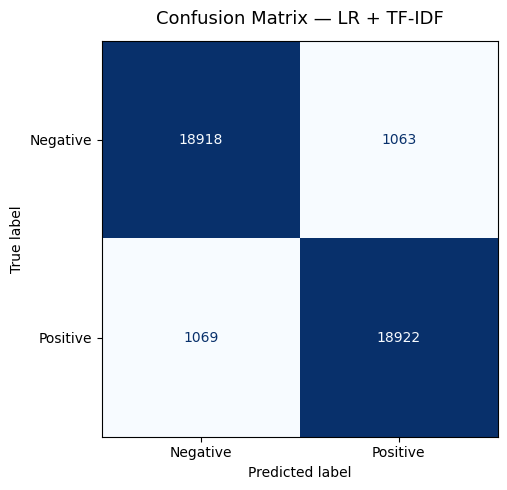

In [29]:
# Evaluate
results_lr_tfidf = evaluate_model(
    "Logistic Regression + TF-IDF",
    y_test, y_pred_lr_tfidf, y_prob_lr_tfidf
)

# Confusion matrix
plot_confusion_matrix(
    "LR + TF-IDF", y_test, y_pred_lr_tfidf,
    save_path=f'{OUTPUT_DIR}/cm_lr_tfidf.png'
)


In [30]:
# Save model
joblib.dump(lr_tfidf, f'{OUTPUT_DIR}/lr_tfidf.joblib')
print("Model saved to Drive.")

Model saved to Drive.


#Naive Bayes

In [31]:
print("Training Complement Naive Bayes on TF-IDF features...")
print("(ComplementNB — designed specifically for text classification)")

t0 = time.time()

nb_tfidf = ComplementNB(alpha=0.1)
nb_tfidf.fit(X_train_tfidf, y_train)

elapsed = time.time() - t0
print(f"Training time: {elapsed:.1f}s")


Training Complement Naive Bayes on TF-IDF features...
(ComplementNB — designed specifically for text classification)
Training time: 0.3s


In [32]:
# Predict
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_prob_nb_tfidf = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]


  Naive Bayes (Complement) + TF-IDF
  Accuracy  : 0.9121  (91.21%)
  Precision : 0.9101
  Recall    : 0.9147
  F1-score  : 0.9124
  ROC-AUC   : 0.9700

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     19981
    Positive       0.91      0.91      0.91     19991

    accuracy                           0.91     39972
   macro avg       0.91      0.91      0.91     39972
weighted avg       0.91      0.91      0.91     39972

Saved: /content/drive/MyDrive/SmartReviewAnalyzer_baseline/cm_nb_tfidf.png


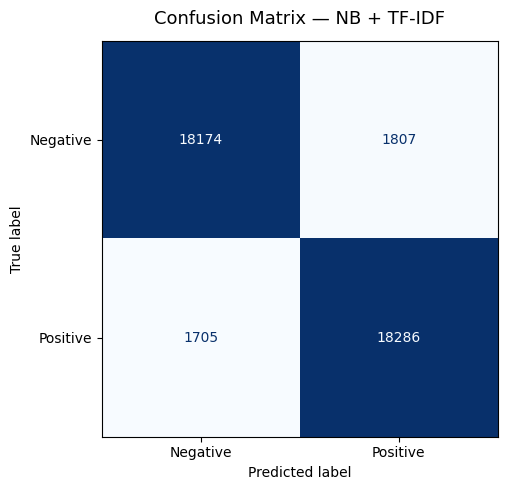

In [33]:
# Evaluate
results_nb_tfidf = evaluate_model(
    "Naive Bayes (Complement) + TF-IDF",
    y_test, y_pred_nb_tfidf, y_prob_nb_tfidf
)
# Confusion matrix
plot_confusion_matrix(
    "NB + TF-IDF", y_test, y_pred_nb_tfidf,
    save_path=f'{OUTPUT_DIR}/cm_nb_tfidf.png'
)

In [34]:
# Save model
joblib.dump(nb_tfidf, f'{OUTPUT_DIR}/nb_tfidf.joblib')
print("Model saved to Drive.")

Model saved to Drive.


#Full comparison table


         BASELINE MODELS — FULL COMPARISON
                                   Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                          
Logistic Regression + TF-IDF         0.9467     0.9468  0.9465  0.9467   0.9886
Naive Bayes (Complement) + TF-IDF    0.9121     0.9101  0.9147  0.9124   0.9700

Saved to /content/drive/MyDrive/SmartReviewAnalyzer_baseline/baseline_comparison.csv


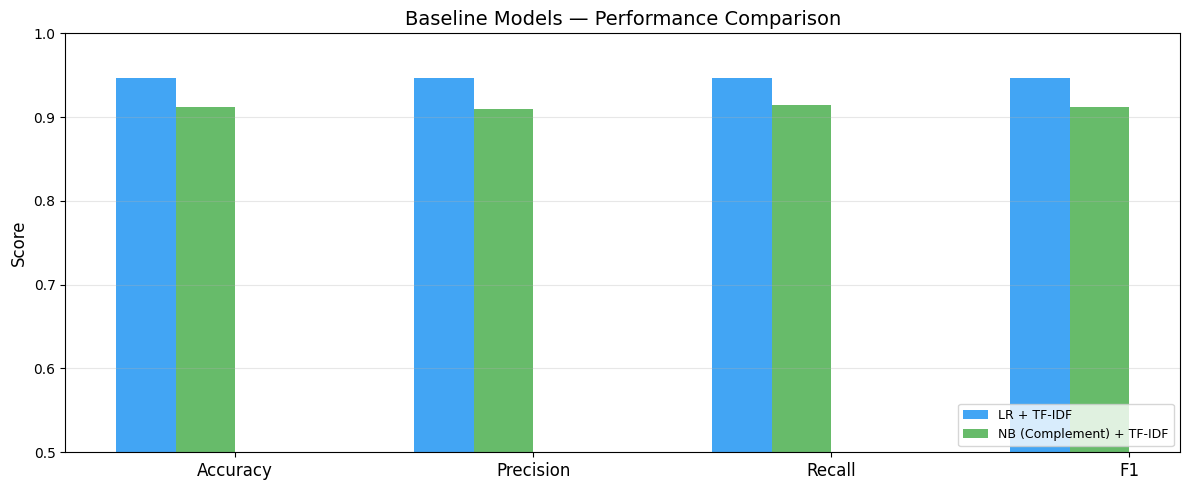

Chart saved.


In [35]:
all_results = [
    results_lr_tfidf,
    results_nb_tfidf
]

df_results = pd.DataFrame(all_results).set_index('Model')
print("\n" + "="*70)
print("         BASELINE MODELS — FULL COMPARISON")
print("="*70)
print(df_results.to_string())

# Save to Drive
df_results.to_csv(f'{OUTPUT_DIR}/baseline_comparison.csv')
print(f"\nSaved to {OUTPUT_DIR}/baseline_comparison.csv")

# Plot comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
df_plot = df_results[metrics]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(metrics))
width   = 0.2
colors  = ['#2196F3', '#4CAF50']

for i, (model_name, row) in enumerate(df_plot.iterrows()):
    short_name = model_name.replace('Logistic Regression', 'LR') \
                           .replace('Naive Bayes', 'NB')
    ax.bar(x + i * width, row.values, width,
           label=short_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline Models — Performance Comparison', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/baseline_comparison.png', dpi=150)
plt.show()
print("Chart saved.")

#ROC curves for both models

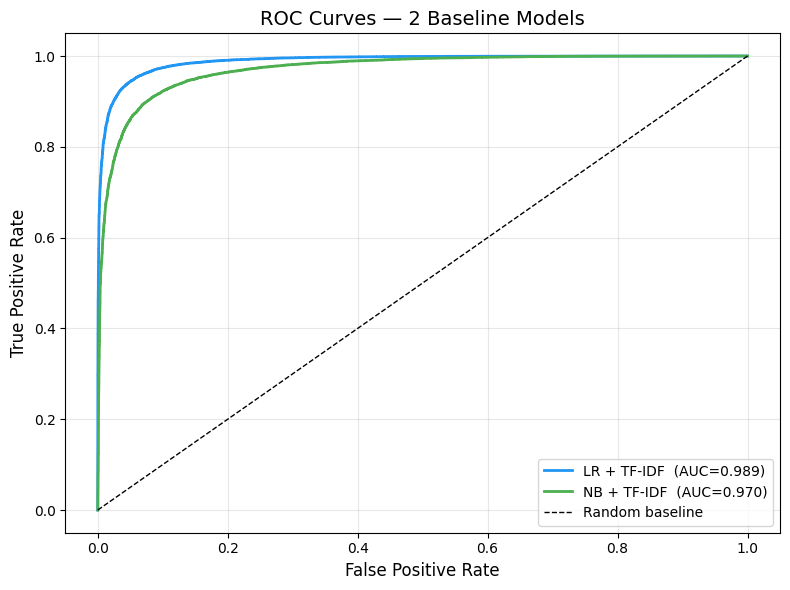

ROC curves saved.


In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    ("LR + TF-IDF",  y_test, y_prob_lr_tfidf),
    ("NB + TF-IDF",  y_test, y_prob_nb_tfidf)
]

colors_roc = ['#2196F3', '#4CAF50']

for (name, y_true, y_prob), color in zip(models_roc, colors_roc):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score   = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc_score:.3f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 2 Baseline Models', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved.")